# **Лабораторная работа №2. Визуализация данных**

В самом начале работы следует подключить нужные нам библиотеки

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

In [2]:
# Set style for nicer plots
plt.rcParams["figure.figsize"] = (10, 6)
sns.set(style="whitegrid")

Перед выполнением следующих заданий вам нужно загрузить на свой гугл-диск файлы `pogoda.csv`, `tips.csv` и `Video_Games_Sales_as_at_22_Dec_2016.csv`. Файлы прикреплены к заданию на Sakai. Также их можно скачать из [папки курса](https://drive.google.com/drive/folders/1pYzTlpXNdc3Jq8X5O1pFlxm2NjhpgnqH?usp=drive_link).

**Если вы работаете в Anaconda, файлы нужно скачать на компьютер и поместить в папку, из которой вам будет удобно с ними работать.**

**Задание 1**  Загрузите набор данных `pogoda.csv` и для каждого параметра постройте график. Требования:
 - Цвет, стиль, толщина линии у графиков не должны повторяться.
 - Каждый график должен быть в своей системе координат, как показано на рисунке 1.
 - Добавьте названия, подписи осей и легенду.

**Примечание**: обратите внимание, что в таблице столбцы разделены символом табуляции. Для открытия необходимо использовать параметр `sep = '\t'`.


=== Задание 1 ===


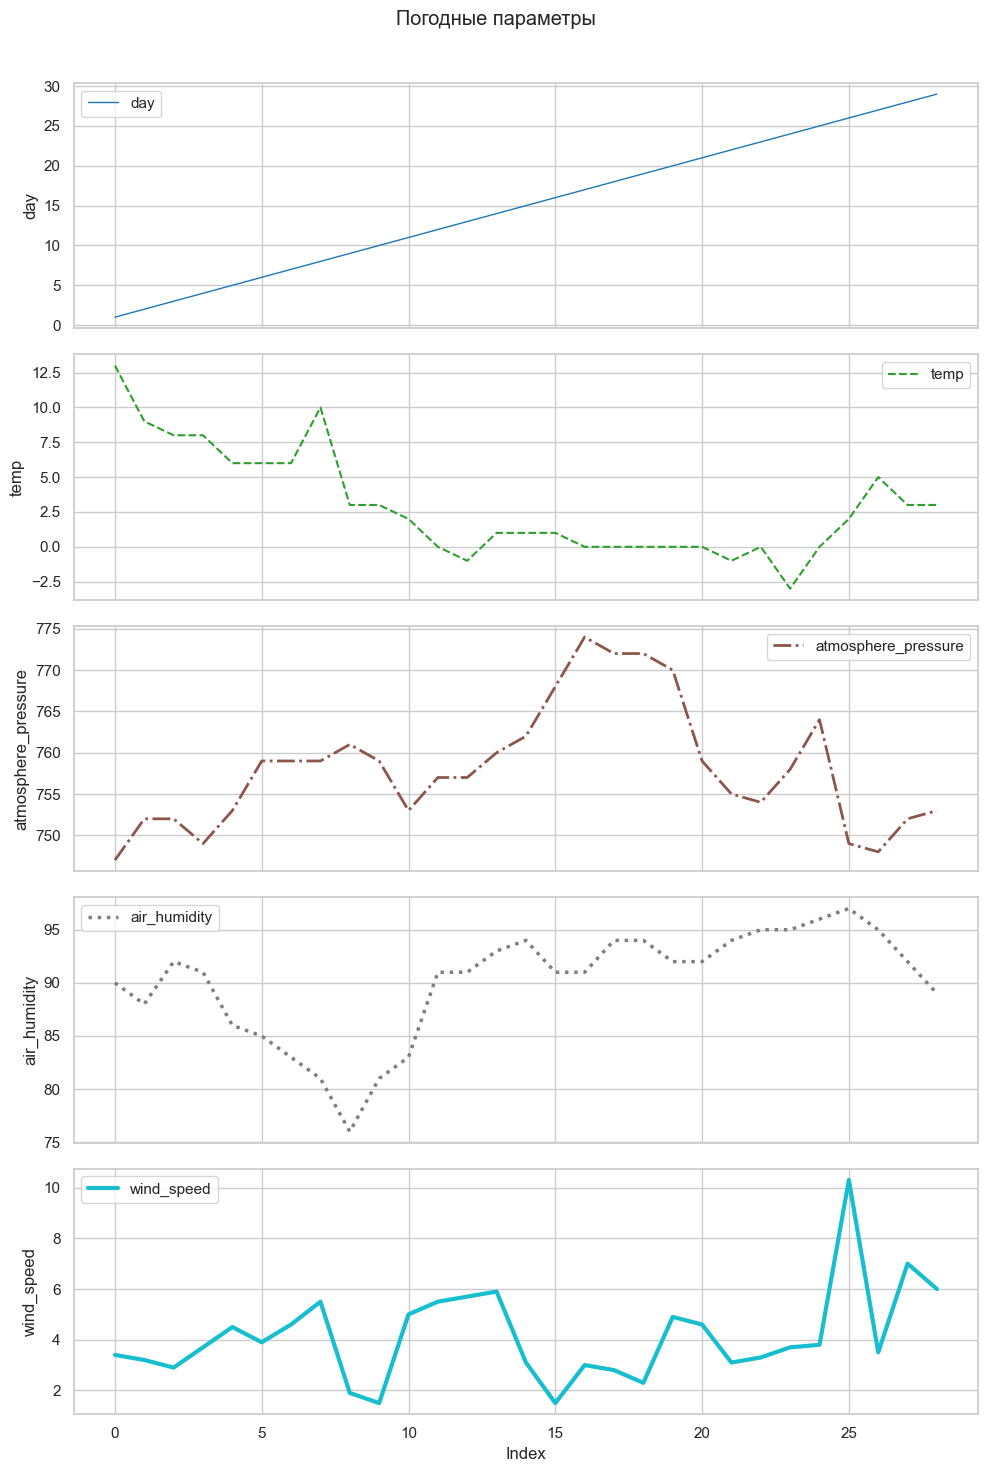

In [3]:
# Напишите здесь решение задания 1
# ------------------------------------------------------------------
# Задание 1: pogoda.csv
# ------------------------------------------------------------------
print("=== Задание 1 ===")

# Загружаем данные (столбцы разделены табуляцией)
df_pogoda = pd.read_csv("pogoda.csv", sep="\t")

# Убедимся, что 'date' — datetime (если есть)
if "date" in df_pogoda.columns:
    df_pogoda["date"] = pd.to_datetime(df_pogoda["date"])

# Параметры (все числовые столбцы)
numeric_cols = df_pogoda.select_dtypes(include=[np.number]).columns.tolist()

# Уникальные стили
colors = plt.cm.tab10(np.linspace(0, 1, len(numeric_cols)))
linestyles = ["-", "--", "-.", ":"] * (len(numeric_cols) // 4 + 1)
linewidths = np.linspace(1, 3, len(numeric_cols))

# Создаём подграфики
fig, axes = plt.subplots(
    len(numeric_cols), 1, figsize=(10, 3 * len(numeric_cols)), sharex=True
)
if len(numeric_cols) == 1:
    axes = [axes]

x = df_pogoda.index if "date" not in df_pogoda.columns else df_pogoda["date"]

for i, col in enumerate(numeric_cols):
    axes[i].plot(
        x,
        df_pogoda[col],
        color=colors[i],
        linestyle=linestyles[i],
        linewidth=linewidths[i],
        label=col,
    )
    axes[i].set_ylabel(col)
    axes[i].legend()
    axes[i].grid(True)

if "date" in df_pogoda.columns:
    axes[-1].set_xlabel("Date")
else:
    axes[-1].set_xlabel("Index")

plt.suptitle("Погодные параметры")
plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()

**Задание 2**. - Загрузите набор данных `tips.csv`. Выполните следующие задания:
1. С помощью библиотеки matplotlib постройте столбчатую диаграмму, где на оси X будут названия дней, а на оси Y сумма чаевых. Вам потребуется сгруппировать данные.
2. Сделайте так, чтобы названия дней располагались по диагонали.
3. Сделайте так, чтобы у каждого дня был свой уникальный цвет.

=== Задание 2 ===


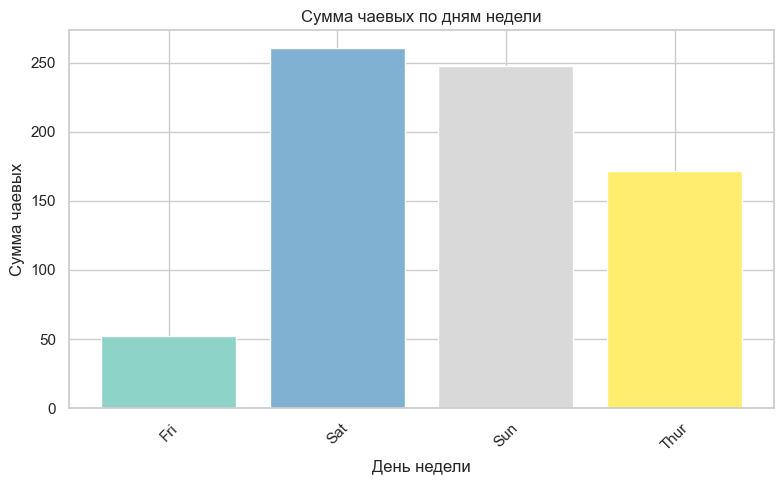

In [4]:
# Напишите здесь решение задания 2
# ------------------------------------------------------------------
# Задание 2: tips.csv
# ------------------------------------------------------------------
print("=== Задание 2 ===")

df_tips = pd.read_csv("tips.csv")

# Группировка: сумма чаевых по дням
tip_by_day = df_tips.groupby("day")["tip"].sum()

# Уникальные цвета для каждого дня
colors = plt.cm.Set3(np.linspace(0, 1, len(tip_by_day)))

plt.figure(figsize=(8, 5))
bars = plt.bar(tip_by_day.index, tip_by_day.values, color=colors)
plt.xlabel("День недели")
plt.ylabel("Сумма чаевых")
plt.title("Сумма чаевых по дням недели")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

**Задание 3**. Загрузите набор данных `Video_Games_Sales_as_at_22_Dec_2016.csv`
1. Удалите из него все записи с пропусками и выведите размеры датафрейма (должно получиться 6825 записи)
2. Удалите лишние параметры. У вас должны остаться: 'Name', 'Platform', 'Year_of_Release', 'Genre', 'NA_Sales', 'EU_Sales', 'JP_Sales','Other_Sales', 'Global_Sales', 'Critic_Score', 'Critic_Count', 'User_Score', 'User_Count', 'Rating'
3. Скорректируйте формат данных. Параметр 'User_Score' должен иметь формат 'float64', 'Year_of_Release' — 'int64', 'User_Count' — 'int64', 'Critic_Count' — 'int64'
4. Выведите полученную таблицу
5. По полученной таблице постройте график продаж видео игр в различных странах в зависимости от года (см. рис. 2).

=== Задание 3 ===
Размер датафрейма после удаления пропусков: (6826, 14)

Очищенный датафрейм:
                    Name Platform  Year_of_Release     Genre  NA_Sales  \
0             Wii Sports      Wii             2006    Sports     41.36   
2         Mario Kart Wii      Wii             2008    Racing     15.68   
3      Wii Sports Resort      Wii             2009    Sports     15.61   
6  New Super Mario Bros.       DS             2006  Platform     11.28   
7               Wii Play      Wii             2006      Misc     13.96   

   EU_Sales  JP_Sales  Other_Sales  Global_Sales  Critic_Score  Critic_Count  \
0     28.96      3.77         8.45         82.53          76.0            51   
2     12.76      3.79         3.29         35.52          82.0            73   
3     10.93      3.28         2.95         32.77          80.0            73   
6      9.14      6.50         2.88         29.80          89.0            65   
7      9.18      2.93         2.84         28.92          58

C:\Users\Dan\AppData\Local\Temp\ipykernel_66008\1921240918.py:27: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_vg_clean['Year_of_Release'] = df_vg_clean['Year_of_Release'].astype('int64')
C:\Users\Dan\AppData\Local\Temp\ipykernel_66008\1921240918.py:28: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_vg_clean['User_Count'] = df_vg_clean['User_Count'].astype('int64')
C:\Users\Dan\AppData\Local\Temp\ipykernel_66008\1921240918.py:29: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slic

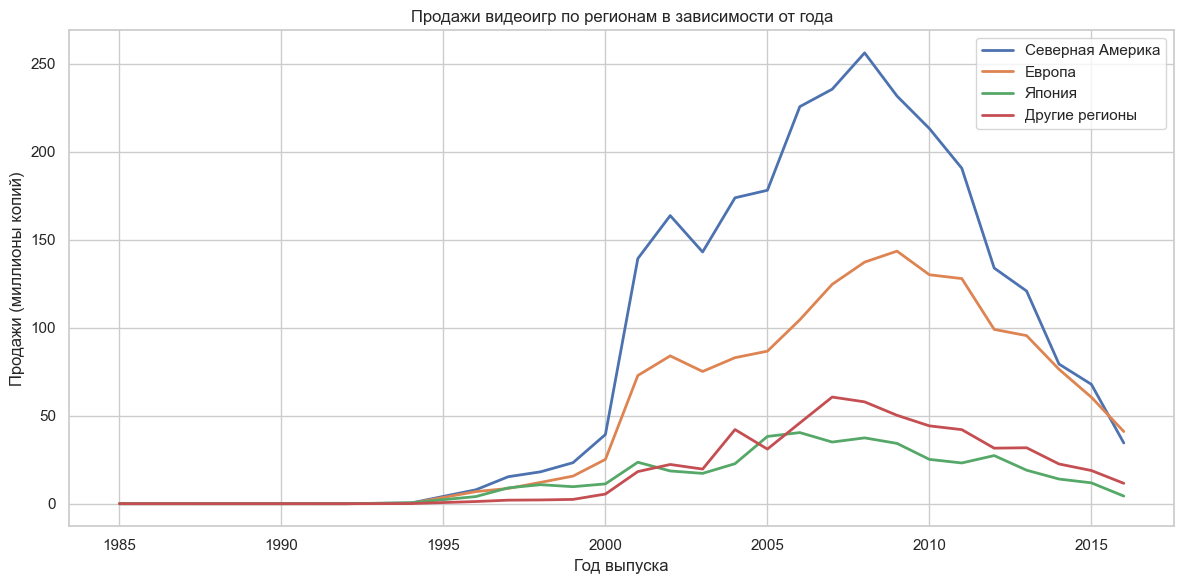

In [5]:
# Напишите здесь решение задания 3
# ------------------------------------------------------------------
# Задание 3: Video Games Sales
# ------------------------------------------------------------------
print("=== Задание 3 ===")

df_vg = pd.read_csv("Video_Games_Sales_as_at_22_Dec_2016.csv")

# 1. Удалить строки с пропусками (в нужных столбцах)
required_cols = [
    "Name",
    "Platform",
    "Year_of_Release",
    "Genre",
    "NA_Sales",
    "EU_Sales",
    "JP_Sales",
    "Other_Sales",
    "Global_Sales",
    "Critic_Score",
    "Critic_Count",
    "User_Score",
    "User_Count",
    "Rating",
]

# 2. Оставить только нужные столбцы
df_vg = df_vg[required_cols].copy()

# 3. Обработка 'User_Score': заменить 'tbd' на NaN и преобразовать в float
df_vg["User_Score"] = pd.to_numeric(df_vg["User_Score"], errors="coerce")

# Удалить строки, где есть пропуски в любых из этих столбцов
df_vg_clean = df_vg.dropna()
print("Размер датафрейма после удаления пропусков:", df_vg_clean.shape)

# Преобразование типов
df_vg_clean["Year_of_Release"] = df_vg_clean["Year_of_Release"].astype("int64")
df_vg_clean["User_Count"] = df_vg_clean["User_Count"].astype("int64")
df_vg_clean["Critic_Count"] = df_vg_clean["Critic_Count"].astype("int64")
df_vg_clean["User_Score"] = df_vg_clean["User_Score"].astype("float64")

# 4. Вывод первых строк
print("\nОчищенный датафрейм:")
print(df_vg_clean.head())

# 5. График продаж по годам
sales_by_year = df_vg_clean.groupby("Year_of_Release")[
    ["NA_Sales", "EU_Sales", "JP_Sales", "Other_Sales"]
].sum()

plt.figure(figsize=(12, 6))
plt.plot(
    sales_by_year.index,
    sales_by_year["NA_Sales"],
    label="Северная Америка",
    linewidth=2,
)
plt.plot(sales_by_year.index, sales_by_year["EU_Sales"], label="Европа", linewidth=2)
plt.plot(sales_by_year.index, sales_by_year["JP_Sales"], label="Япония", linewidth=2)
plt.plot(
    sales_by_year.index,
    sales_by_year["Other_Sales"],
    label="Другие регионы",
    linewidth=2,
)

plt.xlabel("Год выпуска")
plt.ylabel("Продажи (миллионы копий)")
plt.title("Продажи видеоигр по регионам в зависимости от года")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

**Задание 4**. С помощью библиотеки `seaborn` постройте распределение оценок критиков `Critic_Score` (рисунок 3) для датасета, загруженного в задании 3.

=== Задание 4 ===


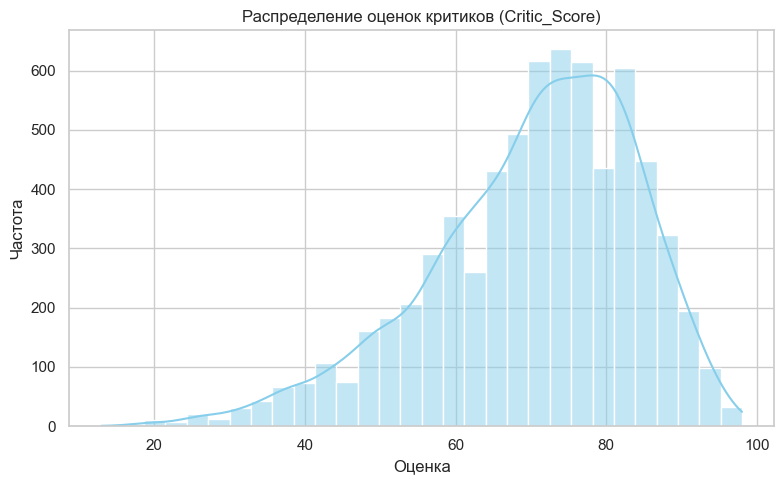

In [6]:
# Напишите здесь решение задания 4
# ------------------------------------------------------------------
# Задание 4: Распределение Critic_Score
# ------------------------------------------------------------------
print("=== Задание 4 ===")

plt.figure(figsize=(8, 5))
sns.histplot(df_vg_clean["Critic_Score"].dropna(), kde=True, bins=30, color="skyblue")
plt.title("Распределение оценок критиков (Critic_Score)")
plt.xlabel("Оценка")
plt.ylabel("Частота")
plt.tight_layout()
plt.show()

**Задание 5**. Для того, чтобы подробнее посмотреть на взаимосвязь двух численных признаков, можно использовать __`joint_plot`__ — это гибрид `scatter plot` и `histogram` (отображаются также гистограммы распределений признаков). Продемонстрируйте, как связаны между собой оценка критиков `Critic_Score` и оценка пользователя `User_Score` для датасета из задания 3.

=== Задание 5 ===


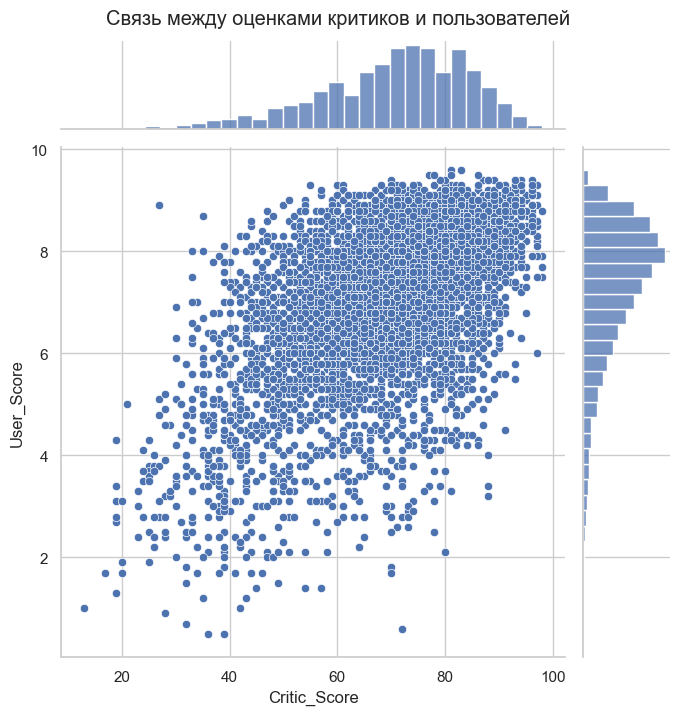

In [7]:
# Напишите здесь решение задания 5
# ------------------------------------------------------------------
# Задание 5: jointplot Critic_Score vs User_Score
# ------------------------------------------------------------------
print("=== Задание 5 ===")

sns.jointplot(
    data=df_vg_clean,
    x="Critic_Score",
    y="User_Score",
    kind="scatter",
    height=7,
    marginal_kws=dict(bins=30, fill=True),
)
plt.suptitle("Связь между оценками критиков и пользователей", y=1.02)
plt.show()

**Задание 6.** Для датасета из задания 3 постройте pair plot для следующих признаков: 'Global_Sales', 'Critic_Score', 'Critic_Count', 'User_Score', 'User_Count'

=== Задание 6 ===


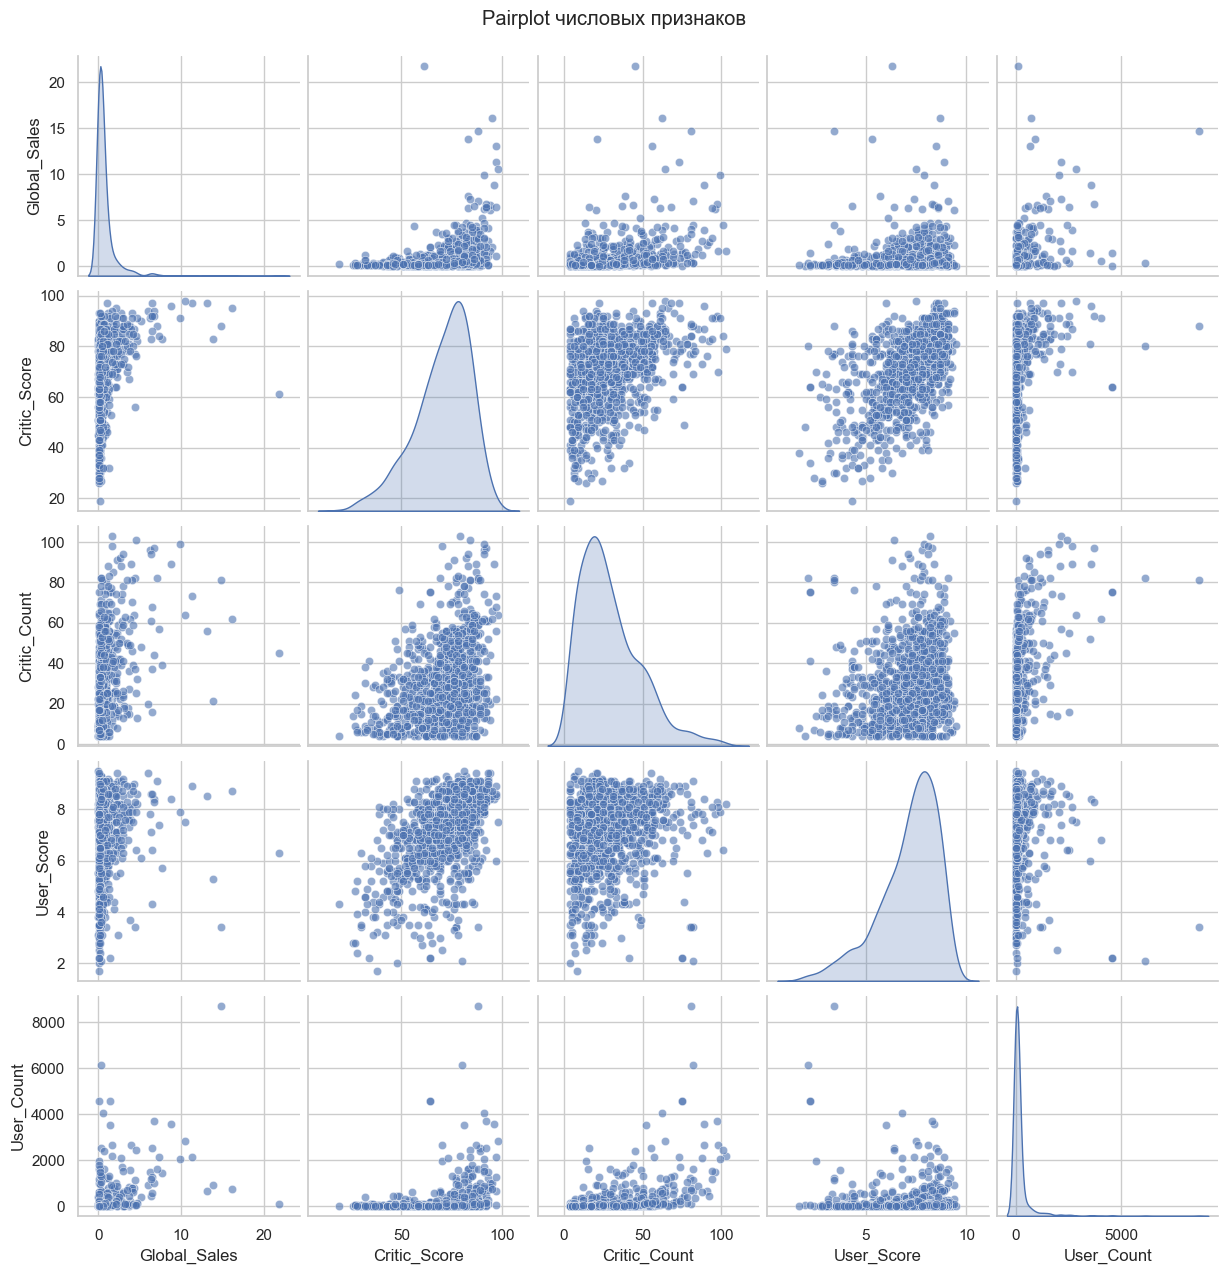

In [8]:
# Напишите здесь решение задания 6
# ------------------------------------------------------------------
# Задание 6: Pairplot
# ------------------------------------------------------------------
print("=== Задание 6 ===")

pair_cols = ["Global_Sales", "Critic_Score", "Critic_Count", "User_Score", "User_Count"]
df_pair = df_vg_clean[pair_cols].dropna()

# Ограничиваем размер для быстроты (опционально)
if len(df_pair) > 1000:
    df_pair = df_pair.sample(1000, random_state=42)

sns.pairplot(df_pair, diag_kind="kde", plot_kws={"alpha": 0.6})
plt.suptitle("Pairplot числовых признаков", y=1.02)
plt.show()